In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings  # Для красивого отображения формул на графиках
using Plots
using BenchmarkTools

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

function sir_ode!(du, u, p, t)
    (S, I, R) = u
    (β, c, γ) = p
    N = S + I + R
    @inbounds begin
        du[1] = -β * c * I / N * S
        du[2] = β * c * I / N * S - γ * I
        du[3] = γ * I
    end
    nothing
end

sir_ode! (generic function with 1 method)

Параметры модели

In [2]:
δt = 0.1
tmax = 40.0
tspan = (0.0, tmax)
u0 = [990.0, 10.0, 0.0]  # S, I, R
p = [0.05, 10.0, 0.25]   # β, c, γ

3-element Vector{Float64}:
  0.05
 10.0
  0.25

Расчет базового репродуктивного числа

In [3]:
R0 = (p[2] * p[1]) / p[3]  # R₀ = (c * β) / γ

2.0

Создание и решение задачи

In [4]:
prob_ode = ODEProblem(sir_ode!, u0, tspan, p)
sol_ode = solve(prob_ode, dt = δt)

retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
  0.0
  0.1
  0.5331242537191838
  1.3919009080055345
  2.61021221798537
  4.181182326044298
  6.180124045228886
  8.664952146237743
 11.691425523605613
 15.27937105275849
 19.0829636767576
 23.423425969211983
 28.429494244539086
 33.29877943214063
 40.0
u: 15-element Vector{Vector{Float64}}:
 [990.0, 10.0, 0.0]
 [989.4990153200853, 10.247898072276143, 0.2530866076385313]
 [987.1852964117763, 11.391111426852984, 1.4235921613706282]
 [981.8312121172252, 14.026022241732, 4.142765641042832]
 [972.139229760034, 18.757816192500677, 9.102954047465346]
 [954.9905468224117, 27.007704055602183, 18.001749121986144]
 [923.070667251774, 41.929769879700146, 34.99956286852594]
 [862.6705746724687, 68.49345686513698, 68.83596846239446]
 [754.3022914470604, 109.7418645302877, 135.95584402265195]
 [595.101409623216, 150.41363540416995, 254.4849549726141]
 [442.01411154679107, 154.80694904937002, 403.17893940383897]
 [326.8

Подготовка данных в DataFrame

In [5]:
df_ode = DataFrame(Tables.table(sol_ode'))
rename!(df_ode, ["S", "I", "R"])
df_ode[!, :t] = sol_ode.t
df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R  # Общая численность популяции

params = [
    (0.05, 10.0, 0.25),  # базовый
    (0.03, 10.0, 0.25),  # меньше заразность
    (0.05, 5.0, 0.25),   # меньше контактов
    (0.05, 10.0, 0.5)    # быстрее выздоровление
]

for (β, c, γ) in params
    p_test = [β, c, γ]
    prob_test = ODEProblem(sir_ode!, u0, tspan, p_test)
    sol_test = solve(prob_test, dt=δt)
    R0_test = (c * β) / γ
    println("β=$β, c=$c, γ=$γ → R₀=$(round(R0_test, digits=2)), пик I=$(round(maximum(sol_test[2,:]), digits=1))")
end

β=0.05, c=10.0, γ=0.25 → R₀=2.0, пик I=154.8
β=0.03, c=10.0, γ=0.25 → R₀=1.2, пик I=22.7
β=0.05, c=5.0, γ=0.25 → R₀=1.0, пик I=10.0
β=0.05, c=10.0, γ=0.5 → R₀=1.0, пик I=10.0


Вывод параметров модели

In [6]:
println("Параметры модели SIR:")
println("β (вероятность заражения) = ", p[1])
println("c (среднее число контактов) = ", p[2])
println("γ (скорость выздоровления) = ", p[3])
println("R₀ = c * β / γ = ", round(R0, digits=3))
println("Средняя продолжительность болезни = ", round(1/p[3], digits=2), " дней")
println("Начальные условия: S₀ = ", u0[1], ", I₀ = ", u0[2], ", R₀ = ", u0[3])

Параметры модели SIR:
β (вероятность заражения) = 0.05
c (среднее число контактов) = 10.0
γ (скорость выздоровления) = 0.25
R₀ = c * β / γ = 2.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S₀ = 990.0, I₀ = 10.0, R₀ = 0.0


1. ОСНОВНОЙ ГРАФИК: динамика всех трех групп

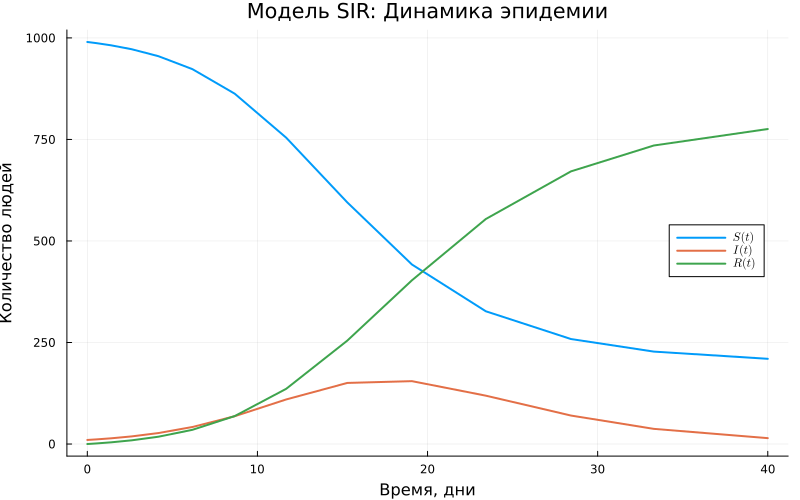

In [7]:
plt1 = @df df_ode plot(:t,
    [:S :I :R],
    label=[L"S(t)" L"I(t)" L"R(t)"],
    xlabel="Время, дни",
    ylabel="Количество людей",
    title="Модель SIR: Динамика эпидемии",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Добавление аннотаций с параметрами

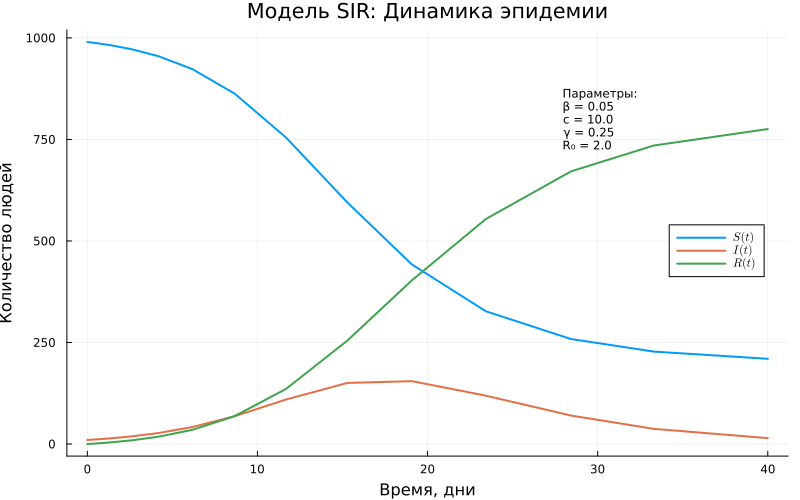

In [8]:
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
    text("Параметры:\nβ = $(p[1])\nc = $(p[2])\nγ = $(p[3])\nR₀ = $(round(R0, digits=2))",
    8, :left))

График только инфицированных (I)

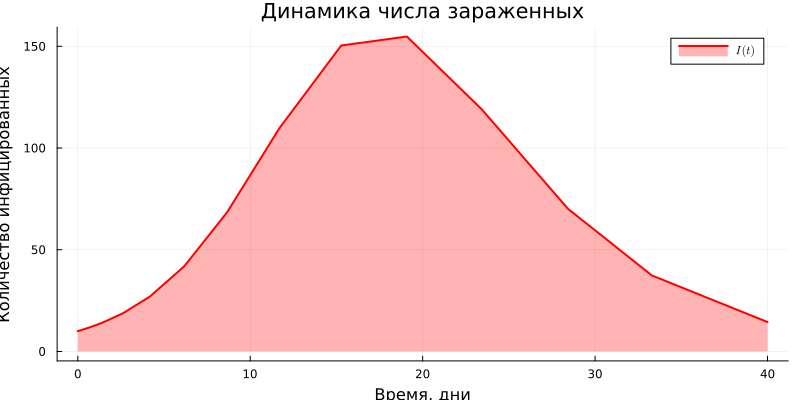

In [9]:
plt2 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных",
    title="Динамика числа зараженных",
    color=:red,
    linewidth=2,
    fill=(0, 0.3, :red),
    grid=true,
    size=(800, 400))

Отметка пика эпидемии

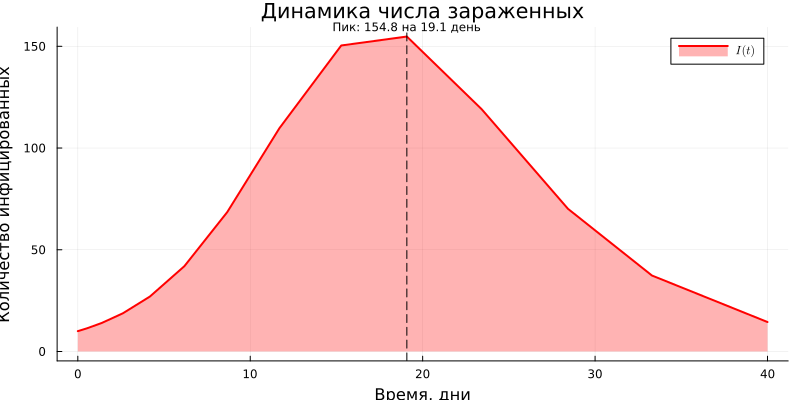

In [10]:
peak_idx = argmax(df_ode.I)
peak_time = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]
vline!(plt2, [peak_time], color=:black, linestyle=:dash, label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
    text("Пик: $(round(peak_value, digits=1)) на $(round(peak_time, digits=1)) день",
    8, :top))

График в логарифмическом масштабе (для анализа экспоненциального роста)

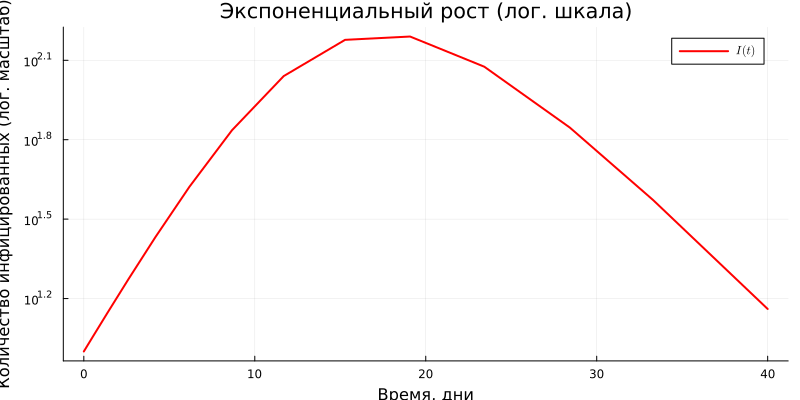

In [11]:
plt3 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных (лог. масштаб)",
    title="Экспоненциальный рост (лог. шкала)",
    yscale=:log10,
    color=:red,
    linewidth=2,
    grid=true,
    size=(800, 400))

График долей населения (в процентах)

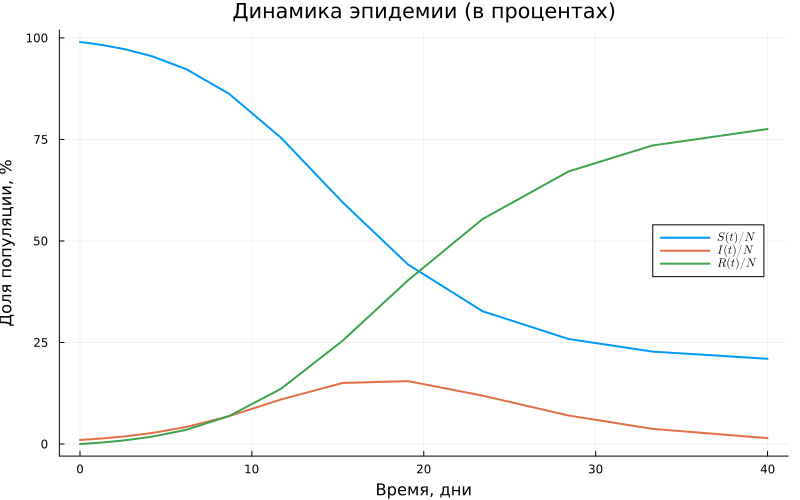

In [12]:
plt4 = @df df_ode plot(:t,
    [:S :I :R] ./ df_ode.N .* 100,
    label=[L"S(t)/N" L"I(t)/N" L"R(t)/N"],
    xlabel="Время, дни",
    ylabel="Доля популяции, %",
    title="Динамика эпидемии (в процентах)",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Горизонтальная линия для порога коллективного иммунитета

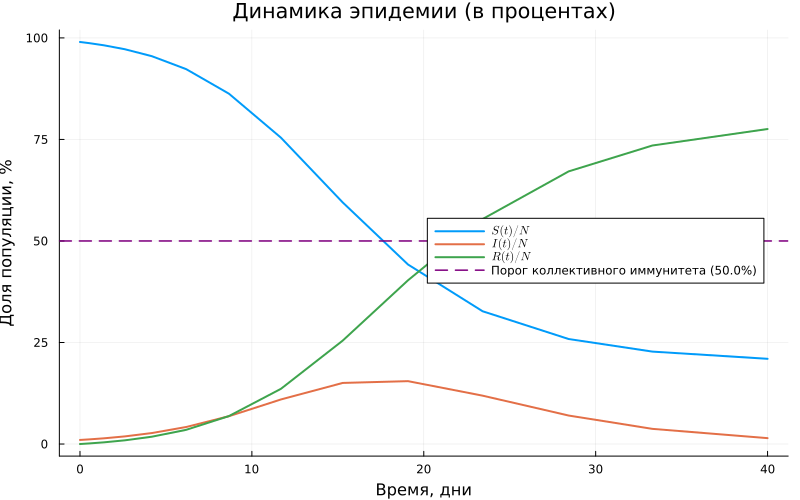

In [13]:
if R0 > 1
    herd_immunity_threshold = (1 - 1/R0) * 100
    hline!(plt4, [herd_immunity_threshold], color=:purple, linestyle=:dash,
        label="Порог коллективного иммунитета ($(round(herd_immunity_threshold, digits=1))%)",
        linewidth=1.5)
end

Фазовый портрет (I vs S)

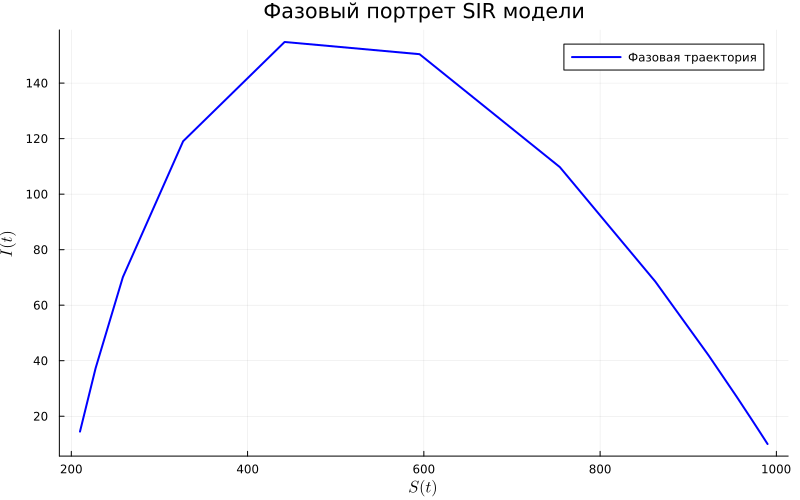

In [14]:
plt5 = plot(df_ode.S, df_ode.I,
    label="Фазовая траектория",
    xlabel=L"S(t)",
    ylabel=L"I(t)",
    title="Фазовый портрет SIR модели",
    color=:blue,
    linewidth=2,
    grid=true,
    size=(800, 500),
    legend=:topright)

Добавление стрелок направления

In [15]:
for i in 1:50:length(df_ode.S)-1
    plot!(plt5, [df_ode.S[i], df_ode.S[i+1]], [df_ode.I[i], df_ode.I[i+1]],
        arrow=:closed, color=:blue, alpha=0.5, label=false)
end

График Rₑ - эффективного репродуктивного числа

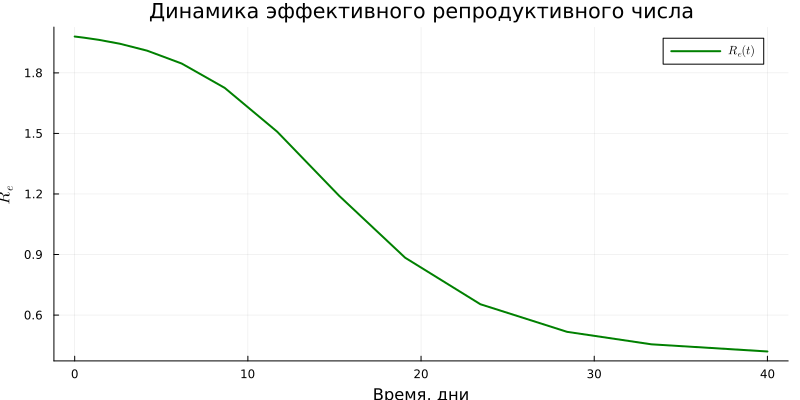

In [16]:
df_ode[!, :Re] = R0 .* df_ode.S ./ df_ode.N
plt6 = @df df_ode plot(:t, :Re,
    label=L"R_e(t)",
    xlabel="Время, дни",
    ylabel=L"R_e",
    title="Динамика эффективного репродуктивного числа",
    color=:green,
    linewidth=2,
    grid=true,
    size=(800, 400))

Горизонтальная линия на уровне 1

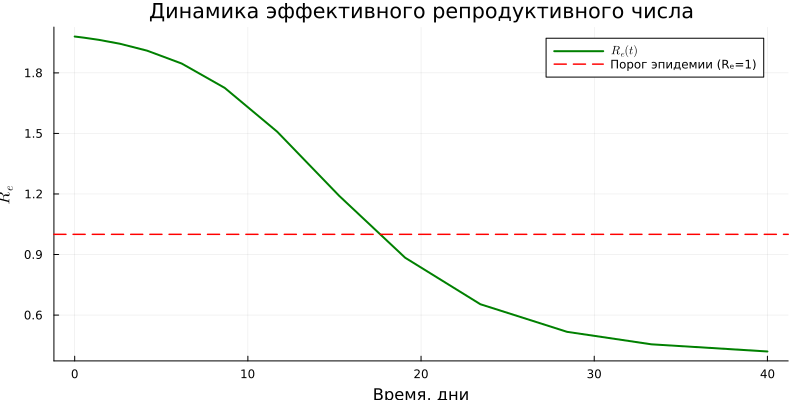

In [17]:
hline!(plt6, [1.0], color=:red, linestyle=:dash, label="Порог эпидемии (Rₑ=1)", linewidth=1.5)

Отметка момента, когда Rₑ становится < 1

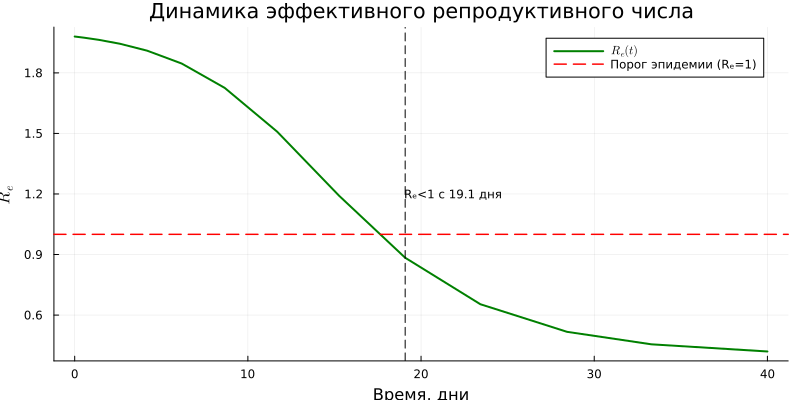

In [18]:
cross_idx = findfirst(x -> x < 1, df_ode.Re)
if !isnothing(cross_idx) && cross_idx > 1
    cross_time = df_ode.t[cross_idx]
    vline!(plt6, [cross_time], color=:black, linestyle=:dash, label=false, linewidth=1)
    annotate!(plt6, cross_time, 1.2,
        text("Rₑ<1 с $(round(cross_time, digits=1)) дня", 8, :left))
end

Компактный график всех кривых в одной панели

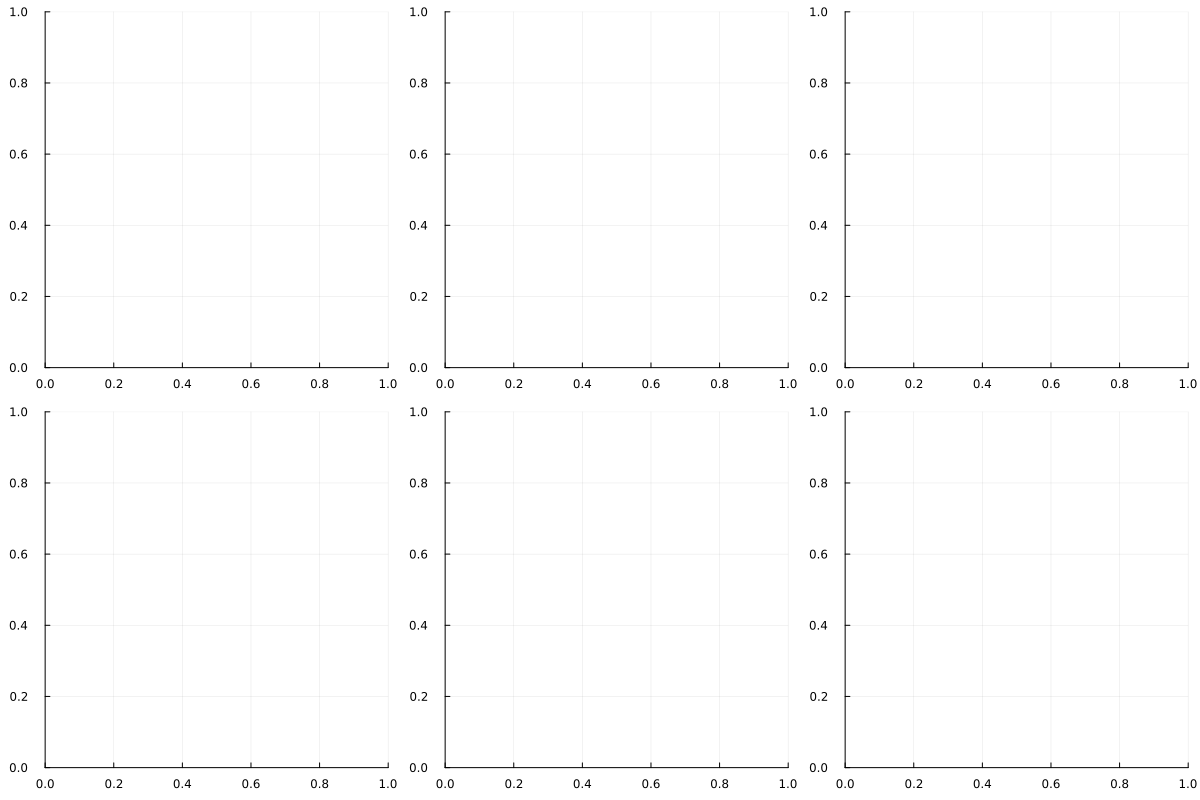

In [19]:
plt7 = plot(layout=(2, 3), size=(1200, 800))

Верхний ряд

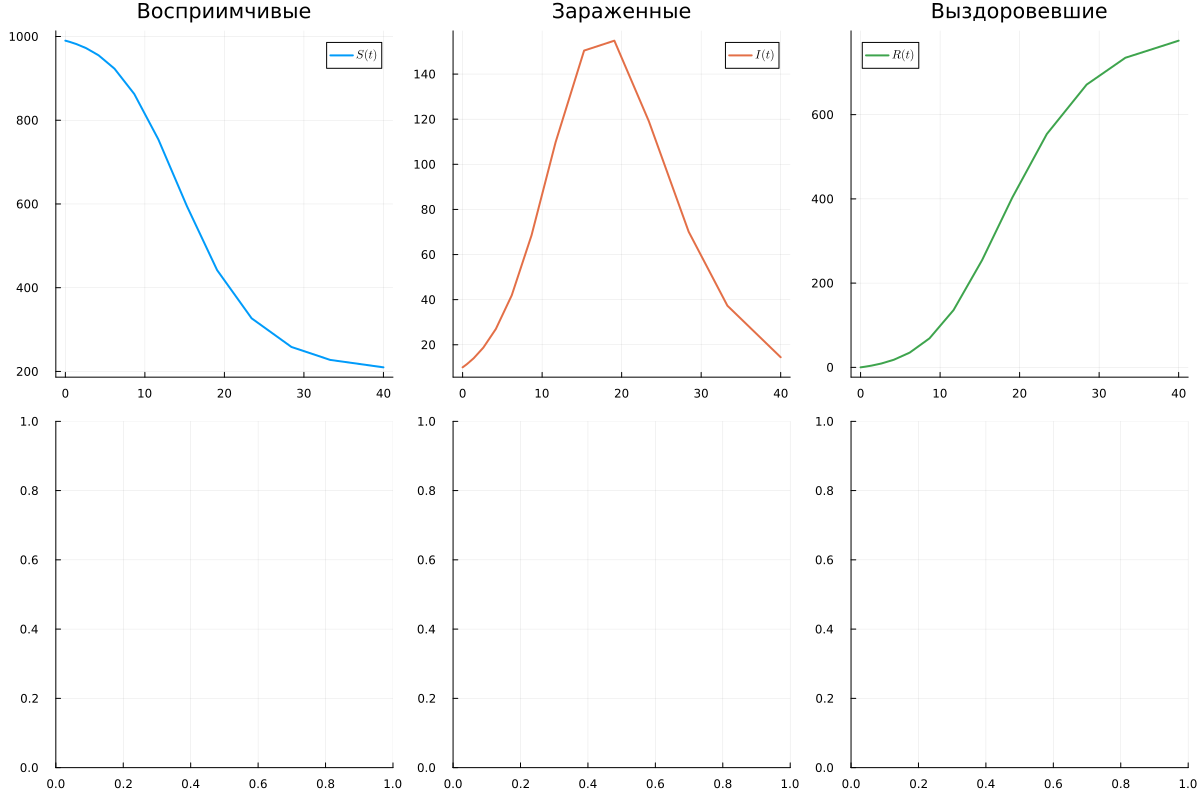

In [20]:
plot!(plt7[1], df_ode.t, df_ode.S, label=L"S(t)", color=1, linewidth=2, title="Восприимчивые")
plot!(plt7[2], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2, title="Зараженные")
plot!(plt7[3], df_ode.t, df_ode.R, label=L"R(t)", color=3, linewidth=2, title="Выздоровевшие")

Нижний ряд

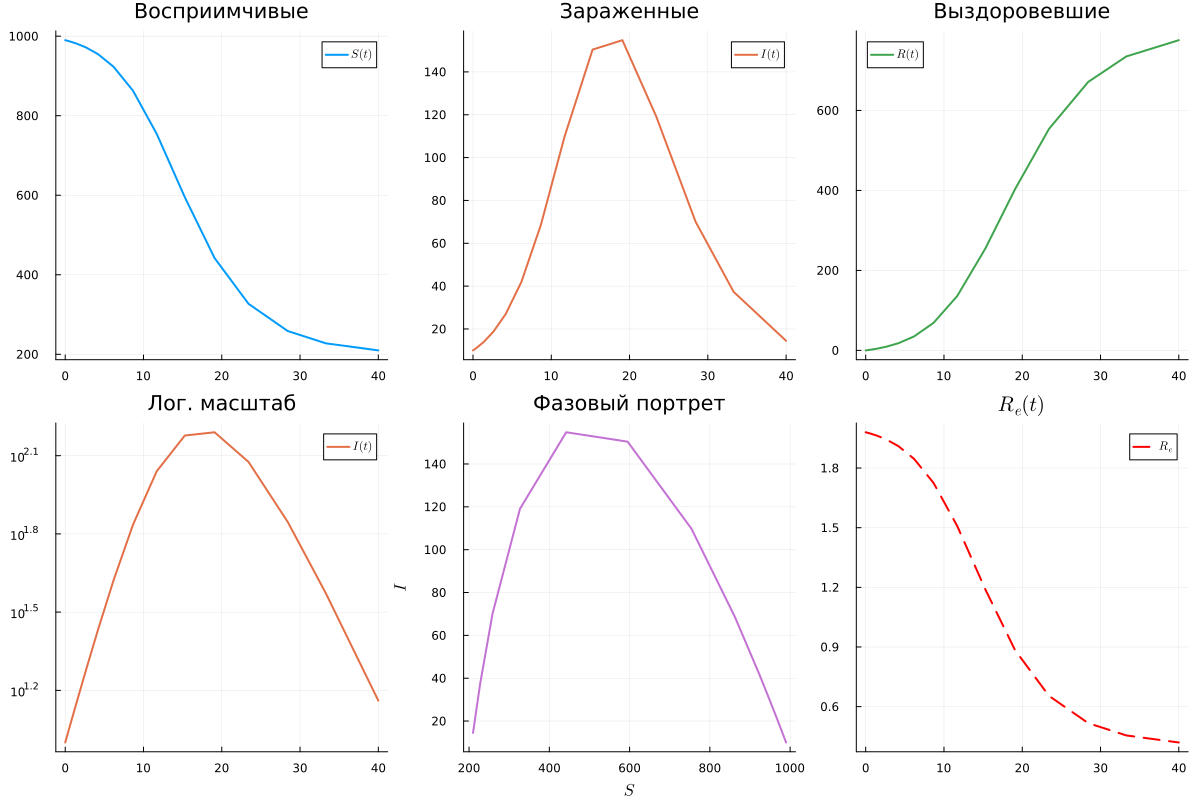

In [21]:
plot!(plt7[4], df_ode.t, df_ode.I, label=L"I(t)", color=2, linewidth=2,
    yscale=:log10, title="Лог. масштаб")
plot!(plt7[5], df_ode.S, df_ode.I, label=false, color=4, linewidth=2,
    title="Фазовый портрет", xlabel=L"S", ylabel=L"I")
plot!(plt7[6], df_ode.t, df_ode.Re, label=L"R_e", color=:green, linewidth=2,
    title=L"R_e(t)", hline=[1.0], linestyle=:dash, linecolor=:red)

Сохранение графиков

In [22]:
savefig(plt1, plotsdir(script_name, "sir_main.png"))
savefig(plt2, plotsdir(script_name, "sir_infected.png"))
savefig(plt3, plotsdir(script_name, "sir_log_scale.png"))
savefig(plt4, plotsdir(script_name, "sir_percentages.png"))
savefig(plt5, plotsdir(script_name, "sir_phase_portrait.png"))
savefig(plt6, plotsdir(script_name, "sir_effective_R.png"))
savefig(plt7, plotsdir(script_name, "sir_panel.png"))

"/home/vaosina/work/study/2026-1/2026-1==simulation-modeling/2026-1--study--simulation-modeling/labs/lab02/project/plots/sir_panel.png"

Бенчмарк для оценки производительности

In [23]:
println("\nБенчмарк решения:")
@benchmark solve(prob_ode, dt = δt)


Бенчмарк решения:


BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  17.974 μs …  2.267 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     21.230 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   25.057 μs ± 39.646 μs  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▇█▆▅▆▆▆▅▅▄▄▃▂▂▂▁▁▁▁                                         ▂
  █████████████████████▇▇▇▆▇▇▇▆▇▆▇▇▇▇▆▇▆▅▆▅▆▅▅▅▆▆▅▄▅▅▅▆▆▅▅▅▅▅ █
  18 μs        Histogram: log(frequency) by time      67.5 μs <

 Memory estimate: 17.53 KiB, allocs estimate: 334.

Дополнительный анализ

In [24]:
println("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
println("Общая численность популяции (контроль): N = ", round(df_ode.N[1], digits=1))
println("Пиковое число зараженных: I_max = ", round(peak_value, digits=1))
println("Время достижения пика: t_peak = ", round(peak_time, digits=1), " дней")
println("Итоговое число переболевших: R(∞) = ", round(df_ode.R[end], digits=1))
println("Доля переболевших: ", round(df_ode.R[end]/df_ode.N[1]*100, digits=1), "%")

if R0 > 1
    println("\nТеоретический анализ:")
    println("  - Порог коллективного иммунитета: ", round((1-1/R0)*100, digits=1), "%")
    println("  - Теоретический пик при S/N = 1/R₀ = ", round(1/R0, digits=3))
end


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
Общая численность популяции (контроль): N = 1000.0
Пиковое число зараженных: I_max = 154.8
Время достижения пика: t_peak = 19.1 дней
Итоговое число переболевших: R(∞) = 775.7
Доля переболевших: 77.6%

Теоретический анализ:
  - Порог коллективного иммунитета: 50.0%
  - Теоретический пик при S/N = 1/R₀ = 0.5


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*